In [26]:
import numpy as np
import torch 
import torch.nn.functional as filter
import torchvision
import matplotlib.pyplot as plt
from time import time
from torchvision import datasets, transforms
from torch import nn, optim

- **torch:** Biblioteca principal do PyTorch para computação tensorial e deep learning; Fornece estruturas de dados como tensores e operações matemáticas otimizadas para GPU `import torch`

- **torch.nn.functional:** Módulo com funções de ativação, loss functions e operações de redes neurais
Contém implementações funcionais de camadas como convoluções, pooling, normalização, etc. `import torch.nn.functional as filter`

- **torchvision:** Biblioteca para visão computacional do PyTorch
Inclui datasets populares, transformações de imagem e modelos pré-treinados `import torchvision`

- ***torchvision.datasets:*** Submódulo com datasets populares como CIFAR, MNIST, ImageNet

- ***torchvision.transforms:*** Submódulo com transformações de imagem como redimensionamento, normalização, augmentação `from torchvision import datasets, transforms`

- ***torch.nn:*** Módulo para construção de redes neurais no PyTorch

- ***torch.optim:*** Módulo com algoritmos de otimização como SGD, Adam, RMSprop `from torch import nn, optim`

In [27]:
# Baixando a base de dados
transform = transforms.ToTensor()
trainset = datasets.MNIST('.MNIST_data/', download=True, train=True, transform=transform) #carrega a parte de treino do dataset
valset = datasets.MNIST('.MNIST_data/', download=True, train=False, transform=transform) #carrega a parte de teste do dataset

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True) #carrega o dataset de treino em lotes de 64 imagens
valloader = torch.utils.data.DataLoader(valset, batch_size=64, shuffle=True) #carrega o dataset de teste em lotes de 64 imagens

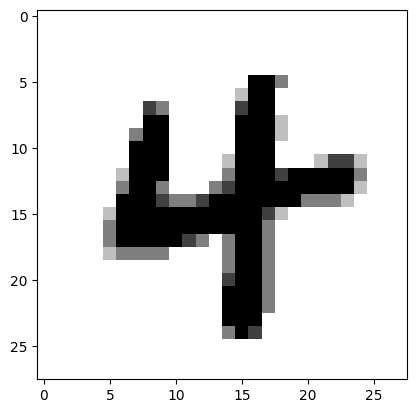

In [28]:
# código para visualizar uma imagem do dataset. Teste inicial!
data_iter = iter(trainloader)
imagens, etiquetas = next(data_iter)
plt.imshow(imagens[0].numpy().squeeze(), cmap='gray_r')

In [29]:
# Definição da arquitetura da rede neural
print(imagens[0].shape) #verifica as dimensoes do tensor de cada imagem
print(etiquetas[0].shape) #verifica as dimensoes do tensor da etiqueta

torch.Size([1, 28, 28])
torch.Size([])


In [30]:
class Modelo(nn.Module):
    def __init__(self):
        super(Modelo, self).__init__()
        self.linear1 = nn.Linear(28*28, 128) #camada totalmente conectada, 784 neuronios de entrada, 128 de saida
        self.linear2 = nn.Linear(128, 64) #segunda camada totalmente conectada, 128 neuronios de entrada, 64 de saida
        self.linear3 = nn.Linear(64, 10) #terceira camada totalmente conectada, 64 neuronios de entrada, 10 de saida (um pra cada numero)
        
    def forward(self, x):
        x = F.relu(self.linear1(x)) #funcao de ativacao ReLU na primeira camada interna 1
        x = F.relu(self.linear2(x)) #funcao de ativacao ReLU na segunda camada interna 2
        x = F.linear3(x) #funcao de ativacao da camada interna 2 para a camada de saída, nesse caso f(x) = x
        return F.log_softmax(x, dim=1) #funcao de ativacao softmax na camada de saida, com reducao logaritmica, dados utilizados para calcular a perda

In [31]:
# otimização da rede
def treino_rede(modelo, trainloader, device):
    otimizador = optim.SGD(modelo.parameters(), lr=0.001, momentum=0.5) #define o otimizador como Stochastic Gradient Descent com taxa de aprendizado de 0.001 e momento de 0.5
    inicio = time() #tempo de duracao do treinamento
    
    criterio = nn.NLLLoss() #define o critério de perda como Negative Log-Likelihood Loss
    EPOCHS = 10 #numero de epochs que o algoritmo rodará. Obs.: Para um bom treinamento no mínimo 100 epochs
    modelo.train() #ativa o modo de treinamento do modelo
    
    for epoch in range(EPOCHS):
        perda_acumulada = 0
        
        for imagens, etiquetas in trainloader:
            imagens = imagens.view(imagens.shape[0], -1) #redimensiona a imagem para um vetor de 784 elementos
            otimizador.zero_grad() #zera os gradientes do otimizador

            saidas = modelo(imagens.to(device)) #faz a forward pass
            perda_instantanea = criterio(saidas, etiquetas.to(device)) #calcula a perda
            perda_instantanea.backward() #faz o backward pass
            otimizador.step() #atualiza os pesos e a bias

            perda_acumulada += perda_instantanea.item() #acumula a perda
            
        else:
            print(f"Epoch {epoch+1}/{EPOCHS} - Perda: {perda_acumulada/len(trainloader):.4f}")
            
    print(f"\nTempo de treinamento: {time()-inicio:.3f} segundos")

In [32]:
# validação da rede
def validacao_rede(modelo, valloader, device):
    total_acerto = 0
    total_imagens = 0
    for imagens, etiquetas in valloader:
        for i in range(len(etiquetas)):
            img = imagens[i].view(1, 784) #redimensiona a imagem para um vetor de 784 elementos
            with torch.no_grad(): #desativa o cálculo de gradientes
                saida = modelo(img.to(device)) #faz a forward pass, saida do modelo em escala logaritmica
            
            ps = torch.exp(saida) #converte a saida do modelo de escala logaritmica para probabilidade
            probabilidade = list(ps.numpy()[0]) #converte a saida do modelo para uma lista de probabilidades
            etiquetas_predita = probabilidade.index(max(probabilidade)) #encontra o indice do maior valor da lista de probabilidades
            etiquetas_certas = etiquetas.numpy()[i] #encontra a etiqueta correta
            if etiquetas_certas == etiquetas_predita: #compara a etiqueta correta com a predita
                total_acerto += 1 #incrementa o total de acertos
            total_imagens +=1

    print(f'Total de imagens testadas = {total_imagens}')
    print(f"\nPrecisão em 10 epochs: {100 * total_acerto / total_imagens:.2f}%")

In [33]:
# inicializando o modelo
modelo = Modelo() #cria o modelo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #define o dispositivo de execução como cuda (GPU) se disponível, caso contrário usa cpu
modelo.to(device) #envia o modelo para o dispositivo de execução

Modelo(
  (linear1): Linear(in_features=784, out_features=128, bias=True)
  (linear2): Linear(in_features=128, out_features=64, bias=True)
  (linear3): Linear(in_features=64, out_features=10, bias=True)
)